# Superstore Sales & Profitability Analysis

## Project Objective

This project analyzes Superstore transactional data using Python and Pandas to identify the key drivers of sales, profitability, losses, discount performance, product performance, customer-segment performance, and geographic profitability.

### Key Questions

- Which categories and sub-categories generate the most sales and profit?
- Which product areas are generating losses?
- How are discounts associated with profitability?
- Which regions and states perform best and worst?
- How does profitability vary across customer segments?
- Where should management focus to improve margins?

### Tools Used

- Python
- Pandas
- Matplotlib
- Kaggle Notebook

### Dataset Note

The dataset contains 9,994 transaction-line records. It does not include Order ID, Customer ID, Product ID, or transaction dates, so the analysis is performed at the available record level rather than at a unique-order or time-series level.


## 1. Import Libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load Dataset


In [ ]:
file_path = "/kaggle/input/datasets/itssuru/super-store/SampleSuperstore.csv"

df = pd.read_csv(file_path)


In [ ]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## 3. Initial Data Inspection

The dataset is inspected for dimensions, column structure, data types, and completeness before any transformation is applied.


In [ ]:
df.shape

(9994, 13)

In [ ]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## 4. Data Quality Audit

The dataset is checked for missing values, duplicate records, categorical consistency, and unusual numerical ranges.


In [ ]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [ ]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 17


In [ ]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.857901,3.789574,0.156203,28.656599
std,623.245124,2.225110,0.206452,234.260115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df[
    ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]
].nunique()

Ship Mode        4
Segment          3
Region           4
Category         3
Sub-Category    17
dtype: int64

In [ ]:
for column in ["Ship Mode", "Segment", "Region", "Category"]:
    print(f"\n{column}:")
    print(df[column].unique())


Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segment:
['Consumer' 'Corporate' 'Home Office']

Region:
['South' 'West' 'Central' 'East']

Category:
['Furniture' 'Office Supplies' 'Technology']


In [ ]:
print("Minimum Profit:", df["Profit"].min())
print("Maximum Profit:", df["Profit"].max())

print("Minimum Discount:", df["Discount"].min())
print("Maximum Discount:", df["Discount"].max())

Minimum Profit: -6599.978
Maximum Profit: 8399.976
Minimum Discount: 0.0
Maximum Discount: 0.8


## 5. Data Cleaning & Feature Engineering

The dataset contains no missing values and the categorical fields appear consistent.

Seventeen exact duplicate rows were identified. However, because the dataset does not contain a unique transaction or order identifier, these records cannot be confirmed as erroneous duplicates. They are therefore retained to avoid removing potentially valid transactions.

Negative profit values are treated as valid loss-making transactions rather than data-quality errors.


In [ ]:
df_clean = df.copy()

print("Raw dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Raw dataset shape: (9994, 13)
Working dataset shape: (9994, 13)


In [ ]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df_clean.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub_category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

In [ ]:
df_clean["postal_code"] = df_clean["postal_code"].astype(str)

df_clean.dtypes

ship_mode        object
segment          object
country          object
city             object
state            object
postal_code      object
region           object
category         object
sub_category     object
sales           float64
quantity          int64
discount        float64
profit          float64
dtype: object

In [ ]:
df_clean["profit_margin"] = (
    df_clean["profit"] / df_clean["sales"] * 100
)

df_clean["profit_status"] = df_clean["profit"].apply(
    lambda x: "Profit" if x > 0 else ("Loss" if x < 0 else "Break-even")
)

df_clean[["sales", "profit", "profit_margin", "profit_status"]].head()

,sales,profit,profit_margin,profit_status
0,261.9600,41.9136,16.00,Profit
1,731.9400,219.5820,30.00,Profit
2,14.6200,6.8714,47.00,Profit
3,957.5775,-383.0310,-40.00,Loss
4,22.3680,2.5164,11.25,Profit


## 6. Executive KPI Analysis

This section summarizes overall commercial performance using sales, profit, margin, quantity, transaction-line, and loss-rate indicators.


In [ ]:
total_sales = df_clean["sales"].sum()
total_profit = df_clean["profit"].sum()
total_quantity = df_clean["quantity"].sum()
total_transactions = len(df_clean)

overall_profit_margin = (total_profit / total_sales) * 100
average_sales_per_line = df_clean["sales"].mean()

loss_transactions = (df_clean["profit"] < 0).sum()
loss_transaction_rate = (loss_transactions / total_transactions) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Transaction Lines: {total_transactions:,}")
print(f"Average Sales per Transaction Line: ${average_sales_per_line:,.2f}")
print(f"Loss-Making Transaction Lines: {loss_transactions:,}")
print(f"Loss-Making Transaction Rate: {loss_transaction_rate:.2f}%")

Total Sales: $2,297,199.86
Total Profit: $286,394.05
Overall Profit Margin: 12.47%
Total Quantity Sold: 37,873
Total Transaction Lines: 9,994
Average Sales per Transaction Line: $229.86
Loss-Making Transaction Lines: 1,871
Loss-Making Transaction Rate: 18.72%


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Overall Profit Margin (%)",
        "Total Quantity Sold",
        "Transaction Lines",
        "Average Sales per Transaction Line",
        "Loss-Making Transaction Rate (%)"
    ],
    "Value": [
        total_sales,
        total_profit,
        overall_profit_margin,
        total_quantity,
        total_transactions,
        average_sales_per_line,
        loss_transaction_rate
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.297200e+06
1,Total Profit,2.863941e+05
2,Overall Profit Margin (%),1.246709e+01
3,Total Quantity Sold,3.787300e+04
4,Transaction Lines,9.994000e+03
5,Average Sales per Transaction Line,2.298579e+02
6,Loss-Making Transaction Rate (%),1.872123e+01


## 7. Category & Sub-Category Analysis


In [ ]:
category_summary = (
    df_clean.groupby("category")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
)

category_summary["profit_margin"] = (
    category_summary["profit"] / category_summary["sales"] * 100
)

category_summary = category_summary.sort_values(
    "sales",
    ascending=False
)

category_summary

,sales,profit,quantity,profit_margin
category,,,,
Technology,836154.0330,145451.9773,6939,17.395357
Furniture,741998.7953,18451.2728,8028,2.486698
Office Supplies,719047.0320,122490.8008,22906,17.035158


### Category Findings

- The dataset generates approximately **$2.30M in sales** and **$286K in profit**.
- Overall profit margin is approximately **12.47%**.
- Around **18.7%** of transaction lines generate a loss.
- Technology is the highest-revenue and highest-profit category.
- Office Supplies also maintains a strong profit margin of approximately **17%**.
- Furniture generates substantial sales but has a very low profit margin of approximately **2.5%**.


In [ ]:
sub_category_summary = (
    df_clean.groupby(["category", "sub_category"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

sub_category_summary["profit_margin"] = (
    sub_category_summary["profit"] /
    sub_category_summary["sales"] * 100
)

sub_category_summary = sub_category_summary.sort_values(
    "profit",
    ascending=False
)

sub_category_summary

,category,sub_category,sales,profit,quantity,avg_discount,profit_margin
14,Technology,Copiers,149528.0300,55617.8249,234,0.161765,37.195585
16,Technology,Phones,330007.0540,44513.7306,3289,0.154556,13.488721
13,Technology,Accessories,167380.3180,41935.6649,2976,0.078452,25.054120
10,Office Supplies,Paper,78479.2060,34053.5693,5178,0.074891,43.391837
6,Office Supplies,Binders,203412.7330,30221.7633,5974,0.372292,14.857361
1,Furniture,Chairs,328449.1030,26590.1663,2356,0.170178,8.095673
11,Office Supplies,Storage,223843.6080,21278.8264,3158,0.074704,9.506113
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,0.166524,16.867517
2,Furniture,Furnishings,91705.1640,13059.1436,3563,0.138349,14.240358
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,0.080315,42.267582


In [ ]:
bottom_subcategories = (
    sub_category_summary
    .sort_values("profit")
    .head(10)
)

bottom_subcategories

,category,sub_category,sales,profit,quantity,avg_discount,profit_margin
3,Furniture,Tables,206964.5320,-17725.4811,1241,0.261285,-8.564502
0,Furniture,Bookcases,114879.9963,-3472.5560,868,0.211140,-3.022768
12,Office Supplies,Supplies,46673.5380,-1189.0995,647,0.076842,-2.547695
8,Office Supplies,Fasteners,3024.2800,949.5182,914,0.082028,31.396504
15,Technology,Machines,189238.6310,3384.7569,440,0.306087,1.788618
9,Office Supplies,Labels,12486.3120,5546.2540,1400,0.068681,44.418672
5,Office Supplies,Art,27118.7920,6527.7870,3000,0.074874,24.071083
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,0.080315,42.267582
2,Furniture,Furnishings,91705.1640,13059.1436,3563,0.138349,14.240358
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,0.166524,16.867517


In [ ]:
top_subcategories = (
    sub_category_summary
    .sort_values("profit", ascending=False)
    .head(10)
)

top_subcategories

,category,sub_category,sales,profit,quantity,avg_discount,profit_margin
14,Technology,Copiers,149528.030,55617.8249,234,0.161765,37.195585
16,Technology,Phones,330007.054,44513.7306,3289,0.154556,13.488721
13,Technology,Accessories,167380.318,41935.6649,2976,0.078452,25.054120
10,Office Supplies,Paper,78479.206,34053.5693,5178,0.074891,43.391837
6,Office Supplies,Binders,203412.733,30221.7633,5974,0.372292,14.857361
1,Furniture,Chairs,328449.103,26590.1663,2356,0.170178,8.095673
11,Office Supplies,Storage,223843.608,21278.8264,3158,0.074704,9.506113
4,Office Supplies,Appliances,107532.161,18138.0054,1729,0.166524,16.867517
2,Furniture,Furnishings,91705.164,13059.1436,3563,0.138349,14.240358
7,Office Supplies,Envelopes,16476.402,6964.1767,906,0.080315,42.267582


In [ ]:
loss_subcategories = sub_category_summary[
    sub_category_summary["profit"] < 0
]

loss_subcategories

,category,sub_category,sales,profit,quantity,avg_discount,profit_margin
12,Office Supplies,Supplies,46673.5380,-1189.0995,647,0.076842,-2.547695
0,Furniture,Bookcases,114879.9963,-3472.5560,868,0.211140,-3.022768
3,Furniture,Tables,206964.5320,-17725.4811,1241,0.261285,-8.564502


### Sub-Category Findings

- Tables are the largest loss-making sub-category, generating approximately **$207K in sales** but losing about **$17.7K**.
- Bookcases are also unprofitable, with approximately **$3.5K in losses**.
- Supplies is the only loss-making Office Supplies sub-category.
- Tables and Bookcases both have relatively high average discount levels.
- Machines remain profitable but operate at a very low profit margin despite substantial sales.


## 8. Discount Analysis


In [ ]:
df_clean["discount_band"] = pd.cut(
    df_clean["discount"],
    bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8],
    labels=[
        "No Discount",
        "Low (0-20%)",
        "Medium (20-40%)",
        "High (40-60%)",
        "Very High (60-80%)"
    ]
)

df_clean[
    ["discount", "discount_band"]
].head()

,discount,discount_band
0,0.00,No Discount
1,0.00,No Discount
2,0.00,No Discount
3,0.45,High (40-60%)
4,0.20,Low (0-20%)


In [ ]:
discount_summary = (
    df_clean.groupby(
        "discount_band",
        observed=True
    )
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_profit=("profit", "mean")
    )
    .reset_index()
)

discount_summary["profit_margin"] = (
    discount_summary["profit"] /
    discount_summary["sales"] * 100
)

discount_summary

,discount_band,transactions,sales,profit,avg_profit,profit_margin
0,No Discount,4798,1.087907e+06,320984.6324,66.899673,29.504773
1,Low (0-20%),3803,8.465222e+05,100785.4745,26.501571,11.905827
2,Medium (20-40%),460,2.341379e+05,-35817.4655,-77.864055,-15.297594
3,High (40-60%),215,7.104821e+04,-28944.1944,-134.624160,-40.738806
4,Very High (60-80%),718,5.758404e+04,-70614.3961,-98.348741,-122.628420


In [ ]:
discount_level_summary = (
    df_clean.groupby("discount")
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

discount_level_summary["profit_margin"] = (
    discount_level_summary["profit"] /
    discount_level_summary["sales"] * 100
)

discount_level_summary

,discount,transactions,sales,profit,profit_margin
0,0.00,4798,1.087907e+06,320984.6324,29.504773
1,0.10,94,5.436935e+04,9029.1770,16.607108
2,0.15,52,2.755852e+04,1418.9915,5.149012
3,0.20,3657,7.645944e+05,90337.3060,11.815063
4,0.30,227,1.032267e+05,-10369.2774,-10.045155
5,0.32,27,1.449346e+04,-2391.1377,-16.498047
6,0.40,206,1.164178e+05,-23057.0504,-19.805437
7,0.45,11,5.484974e+03,-2493.1111,-45.453472
8,0.50,66,5.891854e+04,-20506.4281,-34.804712
9,0.60,138,6.644700e+03,-5944.6552,-89.464614


In [ ]:
furniture_discount_summary = (
    df_clean[df_clean["category"] == "Furniture"]
    .groupby("discount")
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

furniture_discount_summary["profit_margin"] = (
    furniture_discount_summary["profit"] /
    furniture_discount_summary["sales"] * 100
)

furniture_discount_summary

,discount,transactions,sales,profit,profit_margin
0,0.00,836,256024.2700,58133.0764,22.706080
1,0.10,76,46634.2470,7111.0119,15.248476
2,0.15,52,27558.5215,1418.9915,5.149012
3,0.20,615,216631.0160,6265.9491,2.892452
4,0.30,222,99470.3500,-10695.3169,-10.752266
5,0.32,27,14493.4588,-2391.1377,-16.498047
6,0.40,75,45614.4060,-16187.3968,-35.487466
7,0.45,11,5484.9740,-2493.1111,-45.453472
8,0.50,54,20983.4700,-12871.1990,-61.339707
9,0.60,138,6644.7000,-5944.6552,-89.464614


### Discount Analysis Findings

- Transactions with no discount generate the strongest overall profit margin at approximately **29.5%**.
- Low discounts of up to 20% remain profitable, but the margin falls substantially to approximately **12%**.
- Discount bands above 20% are loss-making on an aggregate basis.
- Very high discounts of 60–80% generate particularly severe losses.
- Furniture follows the same pattern: profitability declines steadily as discount increases.
- Furniture remains marginally profitable at a 20% discount, but becomes loss-making from approximately 30% discount onward.
- The results indicate a strong negative association between discount intensity and profitability, although product mix and regional effects should also be considered.


## 9. Regional & State Analysis


In [ ]:
region_summary = (
    df_clean.groupby("region")
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

region_summary["profit_margin"] = (
    region_summary["profit"] /
    region_summary["sales"] * 100
)

region_summary = region_summary.sort_values(
    "profit",
    ascending=False
)

region_summary

,region,transactions,sales,profit,quantity,avg_discount,profit_margin
3,West,3203,725457.8245,108417.4781,12266,0.109335,14.944698
1,East,2848,678781.2400,91522.7800,10618,0.145365,13.483399
2,South,1620,391720.9050,46749.4303,6209,0.147253,11.934372
0,Central,2323,501239.8908,39704.3625,8780,0.240353,7.921230


In [ ]:
region_category_summary = (
    df_clean.groupby(["region", "category"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

region_category_summary["profit_margin"] = (
    region_category_summary["profit"] /
    region_category_summary["sales"] * 100
)

region_category_summary.sort_values("profit")

,region,category,sales,profit,avg_discount,profit_margin
0,Central,Furniture,163797.1638,-2871.0494,0.297380,-1.752808
3,East,Furniture,208291.2040,3046.1658,0.154077,1.462455
6,South,Furniture,117297.6840,6771.2061,0.121536,5.772668
1,Central,Office Supplies,167026.4150,8879.9799,0.252743,5.316512
9,West,Furniture,252612.7435,11504.9503,0.131400,4.554382
7,South,Office Supplies,125651.3130,19986.3928,0.167437,15.906235
8,South,Technology,148771.9080,19991.8314,0.107850,13.437908
2,Central,Technology,170416.3120,33695.4320,0.133095,19.772422
4,East,Office Supplies,205516.0550,41014.5791,0.142932,19.956873
11,West,Technology,251991.8320,44302.6788,0.133890,17.580998


In [ ]:
furniture_region_summary = (
    df_clean[df_clean["category"] == "Furniture"]
    .groupby("region")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

furniture_region_summary["profit_margin"] = (
    furniture_region_summary["profit"] /
    furniture_region_summary["sales"] * 100
)

furniture_region_summary.sort_values("profit")

,region,sales,profit,avg_discount,profit_margin
0,Central,163797.1638,-2871.0494,0.297380,-1.752808
1,East,208291.2040,3046.1658,0.154077,1.462455
2,South,117297.6840,6771.2061,0.121536,5.772668
3,West,252612.7435,11504.9503,0.131400,4.554382


In [ ]:
state_summary = (
    df_clean.groupby("state")
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

state_summary["profit_margin"] = (
    state_summary["profit"] /
    state_summary["sales"] * 100
)

state_summary = state_summary.sort_values(
    "profit",
    ascending=False
)

state_summary.head(10)

,state,transactions,sales,profit,avg_discount,profit_margin
3,California,2001,457687.6315,76380.4163,0.072764,16.688329
30,New York,1128,310876.2710,74038.5486,0.055319,23.816082
45,Washington,506,138641.2700,33402.6517,0.064032,24.092863
20,Michigan,255,76269.6140,24461.1876,0.007059,32.071996
44,Virginia,224,70636.7200,18597.9504,0.000000,26.329012
12,Indiana,149,53555.3600,18382.9363,0.000000,34.325110
9,Georgia,184,49095.8400,16250.0433,0.000000,33.098615
15,Kentucky,139,36591.7500,11199.6966,0.000000,30.607163
21,Minnesota,89,29863.1500,10823.1874,0.000000,36.242618
6,Delaware,96,27451.0690,9977.3748,0.006250,36.346034


In [ ]:
bottom_states = (
    state_summary
    .sort_values("profit")
    .head(10)
)

bottom_states

,state,transactions,sales,profit,avg_discount,profit_margin
41,Texas,985,170188.0458,-25729.3563,0.370193,-15.118192
33,Ohio,469,78258.1360,-16971.3766,0.324947,-21.686405
36,Pennsylvania,587,116511.9140,-15559.9603,0.328620,-13.354823
11,Illinois,492,80166.1010,-12607.8870,0.390041,-15.727205
31,North Carolina,249,55603.1640,-7490.9122,0.283534,-13.472097
4,Colorado,182,32108.1180,-6527.8579,0.316484,-20.330864
40,Tennessee,183,30661.8730,-5341.6936,0.291257,-17.421289
1,Arizona,224,35282.0010,-3427.9246,0.303571,-9.715789
8,Florida,383,89473.7080,-3399.3017,0.299347,-3.799219
35,Oregon,124,17431.1500,-1190.4705,0.288710,-6.829558


In [ ]:
furniture_state_summary = (
    df_clean[df_clean["category"] == "Furniture"]
    .groupby("state")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

furniture_state_summary["profit_margin"] = (
    furniture_state_summary["profit"] /
    furniture_state_summary["sales"] * 100
)

furniture_state_summary.sort_values("profit").head(10)

,state,sales,profit,avg_discount,profit_margin
40,Texas,60593.2918,-10436.1419,0.422970,-17.223263
11,Illinois,28274.5220,-9076.2894,0.468293,-32.100594
35,Pennsylvania,39354.9310,-7196.7199,0.276800,-18.286704
32,Ohio,24199.1450,-4206.3212,0.284946,-17.382107
31,North Carolina,15155.4840,-3486.4633,0.238095,-23.004632
1,Arizona,13525.2910,-2744.9228,0.285714,-20.294741
4,Colorado,13243.0370,-2683.1342,0.311765,-20.260717
8,Florida,22987.0380,-2254.9807,0.232353,-9.809792
39,Tennessee,13506.7320,-2208.6291,0.235556,-16.352061
34,Oregon,6338.1300,-1487.5769,0.342857,-23.470281


### Regional & State Findings

- The West is the strongest region, generating approximately **$725K in sales** and **$108K in profit** with a **14.9% margin**.
- The Central region is the weakest overall performer, with a profit margin of approximately **7.9%** and the highest average discount level.
- Furniture is loss-making in the Central region.
- Texas generates the largest absolute state-level loss.
- Illinois, Pennsylvania, Ohio, North Carolina, and several other states also contribute material losses.
- Furniture losses are concentrated in a relatively small group of states, particularly Texas and Illinois, where average Furniture discount levels are high.


## 10. Customer Segment Analysis


In [ ]:
segment_summary = (
    df_clean.groupby("segment")
    .agg(
        transactions=("sales", "size"),
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

segment_summary["profit_margin"] = (
    segment_summary["profit"] /
    segment_summary["sales"] * 100
)

segment_summary = segment_summary.sort_values(
    "profit",
    ascending=False
)

segment_summary

,segment,transactions,sales,profit,quantity,avg_discount,profit_margin
0,Consumer,5191,1.161400e+06,134116.2384,19521,0.158141,11.547804
1,Corporate,3020,7.061464e+05,91979.1340,11608,0.158228,13.025506
2,Home Office,1783,4.296531e+05,60298.6785,6744,0.147128,14.034269


In [ ]:
segment_category_summary = (
    df_clean.groupby(["segment", "category"])
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

segment_category_summary["profit_margin"] = (
    segment_category_summary["profit"] /
    segment_category_summary["sales"] * 100
)

segment_category_summary.sort_values(
    "profit"
)

,segment,category,sales,profit,avg_discount,profit_margin
6,Home Office,Furniture,121930.6975,3875.3784,0.165000,3.178345
0,Consumer,Furniture,391048.3120,6991.0786,0.176739,1.787779
3,Corporate,Furniture,229019.7858,7584.8158,0.174071,3.311860
7,Home Office,Office Supplies,124418.4340,25933.1596,0.147451,20.843503
8,Home Office,Technology,183304.0170,30490.1405,0.127193,16.633646
4,Corporate,Office Supplies,230676.4620,40227.3202,0.160604,17.438849
5,Corporate,Technology,246450.1190,44166.9980,0.131949,17.921273
1,Consumer,Office Supplies,363952.1360,56330.3210,0.158746,15.477398
2,Consumer,Technology,406399.8970,70794.8388,0.134385,17.419994


In [ ]:
furniture_segment_summary = (
    df_clean[df_clean["category"] == "Furniture"]
    .groupby("segment")
    .agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

furniture_segment_summary["profit_margin"] = (
    furniture_segment_summary["profit"] /
    furniture_segment_summary["sales"] * 100
)

furniture_segment_summary

,segment,sales,profit,avg_discount,profit_margin
0,Consumer,391048.3120,6991.0786,0.176739,1.787779
1,Corporate,229019.7858,7584.8158,0.174071,3.311860
2,Home Office,121930.6975,3875.3784,0.165000,3.178345


### Customer Segment Findings

- The Consumer segment generates the highest sales and total profit.
- Home Office has the strongest overall profit margin at approximately **14.0%**.
- Corporate also performs relatively well with a margin of approximately **13.0%**.
- Consumer has the lowest overall segment margin at approximately **11.5%**.
- Furniture profitability remains weak across all three customer segments.
- This suggests that Furniture's profitability problem is more strongly associated with sub-category, geography, and discounting than with one specific customer segment.


## 11. Data Visualization

The following charts summarize the most important commercial patterns identified in the analysis.


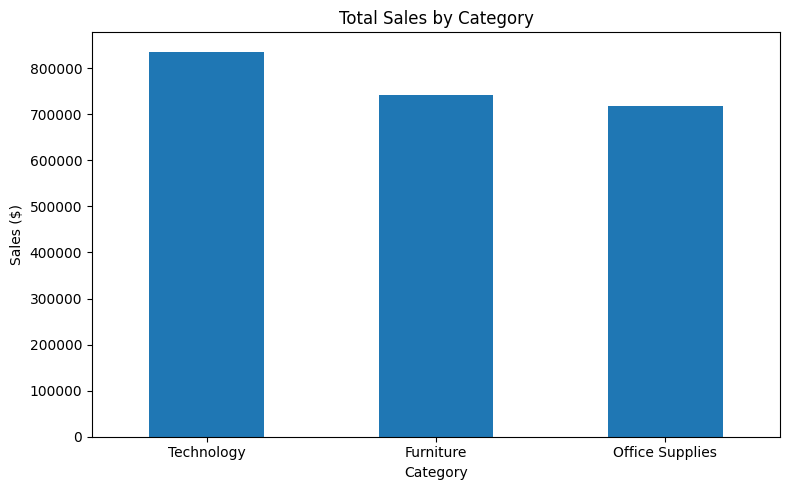

In [ ]:
category_plot = (
    df_clean.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_plot.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

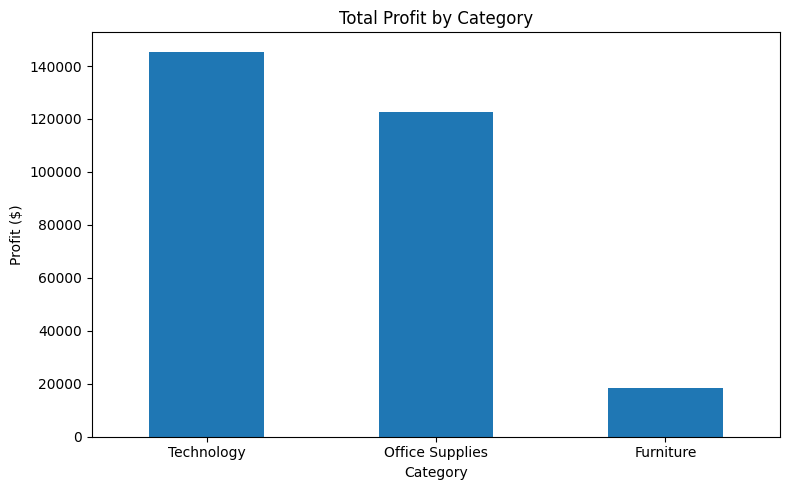

In [ ]:
category_profit_plot = (
    df_clean.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_profit_plot.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

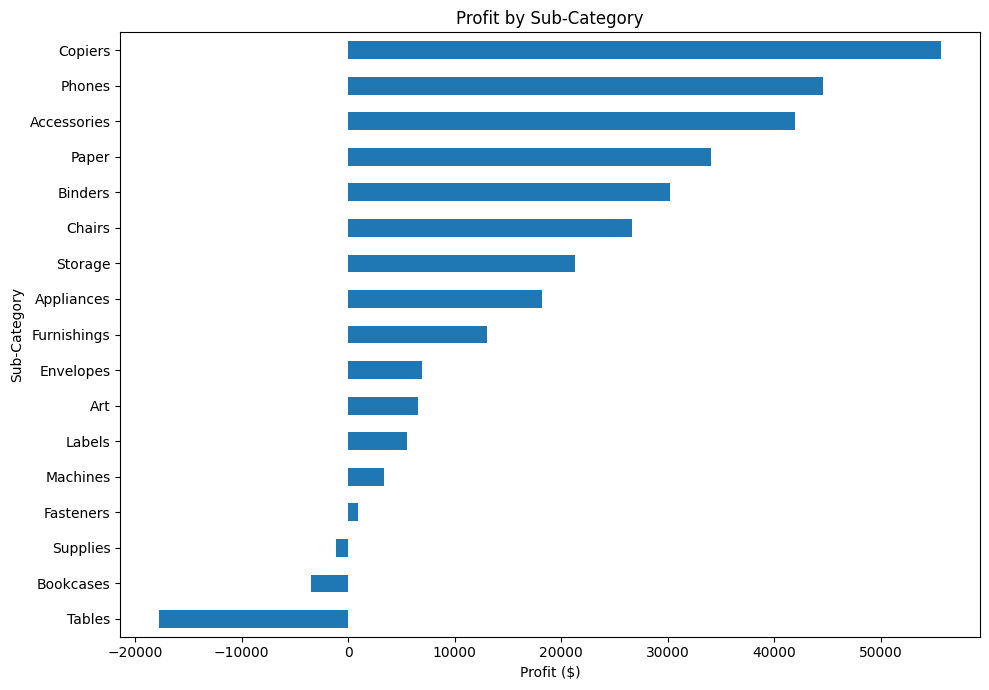

In [ ]:
subcat_profit_plot = (
    df_clean.groupby("sub_category")["profit"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10, 7))
subcat_profit_plot.plot(kind="barh")

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

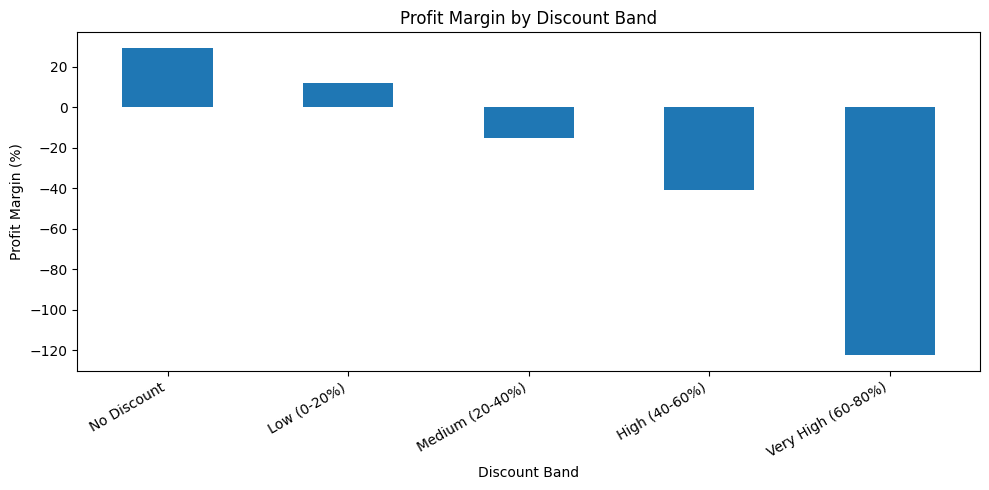

In [ ]:
discount_plot = (
    discount_summary
    .set_index("discount_band")["profit_margin"]
)

plt.figure(figsize=(10, 5))
discount_plot.plot(kind="bar")

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

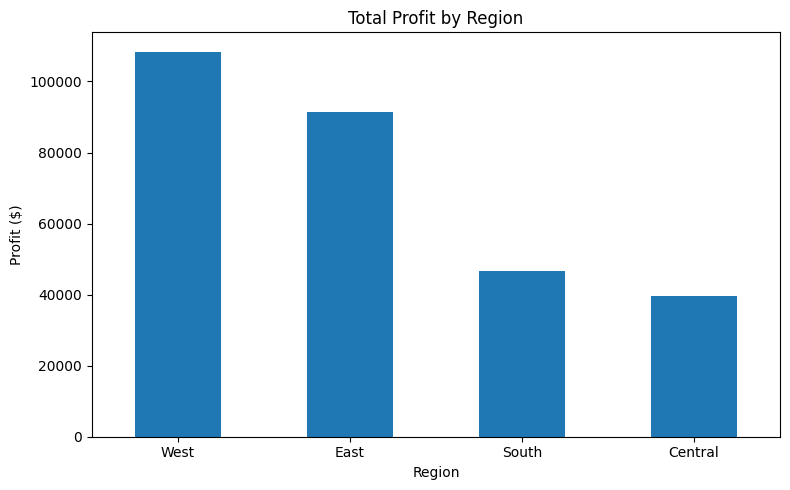

In [ ]:
region_profit_plot = (
    region_summary
    .set_index("region")["profit"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
region_profit_plot.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

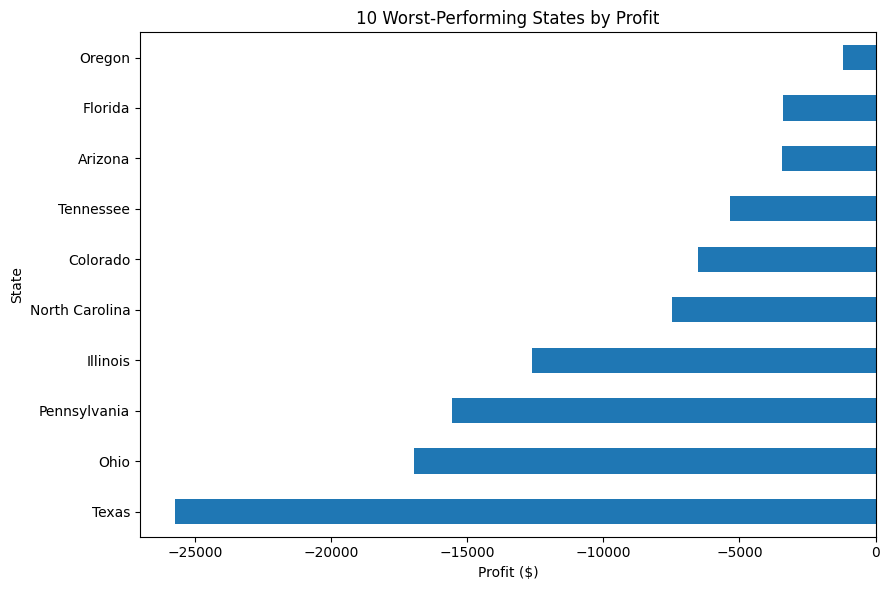

In [ ]:
bottom_states_plot = (
    state_summary
    .sort_values("profit")
    .head(10)
    .set_index("state")["profit"]
)

plt.figure(figsize=(9, 6))
bottom_states_plot.plot(kind="barh")

plt.title("10 Worst-Performing States by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## 12. Executive Summary

This project analyzed 9,994 Superstore transaction records to evaluate sales performance,
profitability, discounting, product categories, customer segments, and geographic performance.

### Key Results

- Total sales were approximately **$2.30 million**.
- Total profit was approximately **$286,000**.
- Overall profit margin was approximately **12.5%**.
- About **18.7% of transaction lines were loss-making**.
- Technology was the strongest category, with approximately **17.4% profit margin**.
- Office Supplies also performed strongly with approximately **17.0% margin**.
- Furniture generated substantial revenue but only approximately **2.5% profit margin**.
- Tables were the largest loss-making sub-category, losing approximately **$17.7K**.
- Bookcases and Supplies were also loss-making.
- Transactions without discounts generated approximately **29.5% margin**.
- Profitability declined sharply as discount levels increased.
- Discount levels above approximately 20% were associated with negative aggregate profitability.
- The Central region had the weakest regional margin at approximately **7.9%** and the highest average discount.
- Texas, Ohio, Pennsylvania, and Illinois were among the largest state-level loss contributors.
- Furniture losses were particularly concentrated in Texas and Illinois.
- Consumer generated the highest absolute sales and profit, while Home Office achieved the highest overall segment margin.


## 13. Business Recommendations

### 1. Review the Discount Strategy

Discounting shows a strong negative association with profitability. Management should review
discount policies, particularly discounts above 20%, and require stronger commercial justification
for high-discount transactions.

### 2. Address Furniture Profitability

Furniture should receive immediate management attention. Tables and Bookcases are generating
negative aggregate profits despite substantial sales volumes.

Pricing, product costs, discount structures, and regional sales practices for these sub-categories
should be reviewed.

### 3. Focus on High-Loss States

Texas, Illinois, Pennsylvania, and Ohio should be investigated further because they contribute
substantial losses, particularly within Furniture.

Regional pricing and promotional policies may require adjustment.

### 4. Protect High-Performing Categories

Technology and Office Supplies generate strong margins and should remain important growth areas.
Growth initiatives should prioritize profitable expansion rather than revenue growth alone.

### 5. Monitor Profitability Alongside Revenue

High sales do not necessarily indicate strong business performance. Furniture demonstrates that
substantial revenue can coexist with weak profitability.

Management reporting should therefore track sales, profit, profit margin, and discount levels together.

### 6. Improve Transaction-Level Data Collection

Future datasets should include Order ID, Customer ID, Product ID, and transaction dates.
These fields would enable customer analysis, order-level KPIs, time-series analysis, repeat-purchase
analysis, and more reliable duplicate detection.


## 14. Final Validation


In [ ]:
print("Final dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Original duplicate records:", df.duplicated().sum())

print("\nTotal Sales:", round(df_clean["sales"].sum(), 2))
print("Total Profit:", round(df_clean["profit"].sum(), 2))
print(
    "Overall Profit Margin:",
    round(df_clean["profit"].sum() / df_clean["sales"].sum() * 100, 2),
    "%"
)

Final dataset shape: (9994, 16)
Missing values: 0
Original duplicate records: 17

Total Sales: 2297199.86
Total Profit: 286394.05
Overall Profit Margin: 12.47 %


## 15. Conclusion

The Superstore business is profitable overall, generating approximately **$2.30 million in sales** and **$286,000 in profit** at an overall profit margin of **12.47%**.

However, profitability varies substantially across products and geographic markets.

Furniture is the primary category of concern. Tables and Bookcases generate negative aggregate profits despite significant sales. The analysis also identified a strong negative association between discount intensity and profitability, with discounts above approximately 20% producing negative aggregate margins.

The Central region has the weakest regional profitability, while several states including Texas, Illinois, Pennsylvania, and Ohio contribute significant losses.

The results indicate that management should prioritize discount discipline, Furniture pricing and cost review, and targeted intervention in loss-making geographic markets.

Future analysis would benefit from additional fields such as Order ID, Customer ID, Product ID, and transaction dates, which would enable time-series analysis, customer-level analysis, order-level KPIs, and more reliable duplicate detection.
